In [9]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    # Python & NumPy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Random seed set to {seed} for reproducibility.")

set_seed(42)

Random seed set to 42 for reproducibility.


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pv_path = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
pd_path = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/train'

def get_classes(dir_path):
    if not os.path.exists(dir_path):
        return []
    return sorted([d for d in os.listdir(dir_path) if os.path.isdir(os.path.join(dir_path, d))])

pv_classes = get_classes(pv_path)
pd_classes = get_classes(pd_path)

def normalize(name):
    # Lowercase everything
    name = name.lower()

    name = name.replace('_', ' ').replace('-', ' ')
    
    name = name.replace(' leaf ', ' ')
    
    return " ".join(name.split())

mapping = {}
print(f"{'PlantVillage (Train)':<30} | {'PlantDoc (Val)':<30} | {'Status'}")
print("-" * 75)

common_classes = []

for pv in pv_classes:
    norm_pv = normalize(pv)
    match = None
    for pd_c in pd_classes:
        if norm_pv == normalize(pd_c):
            match = pd_c
            break
    
    status = "MATCH" if match else "No Match"
    print(f"{pv:<30} | {str(match):<30} | {status}")
    
    if match:
        mapping[pv] = match
        common_classes.append(pv)

print(f"\nFound {len(mapping)} common classes out of {len(pv_classes)} total training classes.")

PlantVillage (Train)           | PlantDoc (Val)                 | Status
---------------------------------------------------------------------------
Pepper__bell___Bacterial_spot  | None                           | No Match
Pepper__bell___healthy         | None                           | No Match
Potato___Early_blight          | Potato leaf early blight       | MATCH
Potato___Late_blight           | Potato leaf late blight        | MATCH
Potato___healthy               | None                           | No Match
Tomato_Bacterial_spot          | Tomato leaf bacterial spot     | MATCH
Tomato_Early_blight            | None                           | No Match
Tomato_Late_blight             | Tomato leaf late blight        | MATCH
Tomato_Leaf_Mold               | None                           | No Match
Tomato_Septoria_leaf_spot      | Tomato Septoria leaf spot      | MATCH
Tomato_Spider_mites_Two_spotted_spider_mite | None                           | No Match
Tomato__Target_Spot         

In [11]:
import os
import pandas as pd

pv_path = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
pd_path = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/train'

def get_classes(path):
    if not os.path.exists(path): return []
    return sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])

pv_classes = get_classes(pv_path)
pd_classes = get_classes(pd_path)

max_len = max(len(pv_classes), len(pd_classes))
pv_classes += [''] * (max_len - len(pv_classes))
pd_classes += [''] * (max_len - len(pd_classes))

# Display side-by-side
df = pd.DataFrame({
    'PlantVillage (Train)': pv_classes, 
    'PlantDoc (Val/Real World)': pd_classes
})

# Adjust pandas settings to show everything
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
print(df)

                           PlantVillage (Train)   PlantDoc (Val/Real World)
0                 Pepper__bell___Bacterial_spot             Apple Scab Leaf
1                        Pepper__bell___healthy                  Apple leaf
2                         Potato___Early_blight             Apple rust leaf
3                          Potato___Late_blight            Bell_pepper leaf
4                              Potato___healthy       Bell_pepper leaf spot
5                         Tomato_Bacterial_spot              Blueberry leaf
6                           Tomato_Early_blight                 Cherry leaf
7                            Tomato_Late_blight         Corn Gray leaf spot
8                              Tomato_Leaf_Mold            Corn leaf blight
9                     Tomato_Septoria_leaf_spot              Corn rust leaf
10  Tomato_Spider_mites_Two_spotted_spider_mite                  Peach leaf
11                          Tomato__Target_Spot    Potato leaf early blight
12        To

In [12]:
CLASS_MAPPING = {
    # PEPPER
    'Pepper__bell___Bacterial_spot': 'Bell_pepper leaf spot',
    'Pepper__bell___healthy': 'Bell_pepper leaf',

    # POTATO (Note: "Potato Healthy" dropped as PlantDoc lacks a match)
    'Potato___Early_blight': 'Potato leaf early blight',
    'Potato___Late_blight': 'Potato leaf late blight',

    # TOMATO
    'Tomato_Bacterial_spot': 'Tomato leaf bacterial spot',
    'Tomato_Early_blight': 'Tomato Early blight leaf',
    'Tomato_Late_blight': 'Tomato leaf late blight',
    'Tomato_Leaf_Mold': 'Tomato mold leaf',
    'Tomato_Septoria_leaf_spot': 'Tomato Septoria leaf spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus': 'Tomato leaf yellow virus',
    'Tomato__Tomato_mosaic_virus': 'Tomato leaf mosaic virus',
    'Tomato_healthy': 'Tomato leaf', 
}

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Copying here for faster use
pv_path = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
pd_path = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/train'

class HybridPlantDataset(Dataset):
    def __init__(self, root_dir, source_type, mapping, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(list(mapping.keys())) # Ensure consistent order
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        print(f"Initializing {source_type.upper()} Dataset...")
        
        valid_images = 0
        
        for pv_name, pd_name in mapping.items():
            # Determine which folder name to look for based on source
            target_folder = pv_name if source_type == 'plantvillage' else pd_name
            class_path = os.path.join(root_dir, target_folder)
            
            # Map back to the Unified Class ID (always based on pv keys)
            label_idx = self.class_to_idx[pv_name]
            
            if os.path.exists(class_path):
                files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                for img_file in files:
                    self.image_paths.append(os.path.join(class_path, img_file))
                    self.labels.append(label_idx)
                valid_images += len(files)
                # print(f"   Loaded {len(files)} images for class: {target_folder}") # Uncomment for verbose
            else:
                print(f"WARNING: Folder not found: {target_folder}")

        print(f"Loaded {valid_images} total images across {len(mapping)} classes.\n")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a dummy tensor or handle gracefully
            return torch.zeros((3, 224, 224)), label

# Applying heavy augmentation to get the "clean" PlantVillage similar to PlantDoc
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet Stats
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("--- BUILDING DATA PIPELINES ---")
train_dataset = HybridPlantDataset(pv_path, 'plantvillage', CLASS_MAPPING, transform=train_transforms)
val_dataset = HybridPlantDataset(pd_path, 'plantdoc', CLASS_MAPPING, transform=val_transforms)

# Create Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

--- BUILDING DATA PIPELINES ---
Initializing PLANTVILLAGE Dataset...
Loaded 17406 total images across 12 classes.

Initializing PLANTDOC Dataset...
Loaded 983 total images across 12 classes.



Generating Domain Shift Visualization...


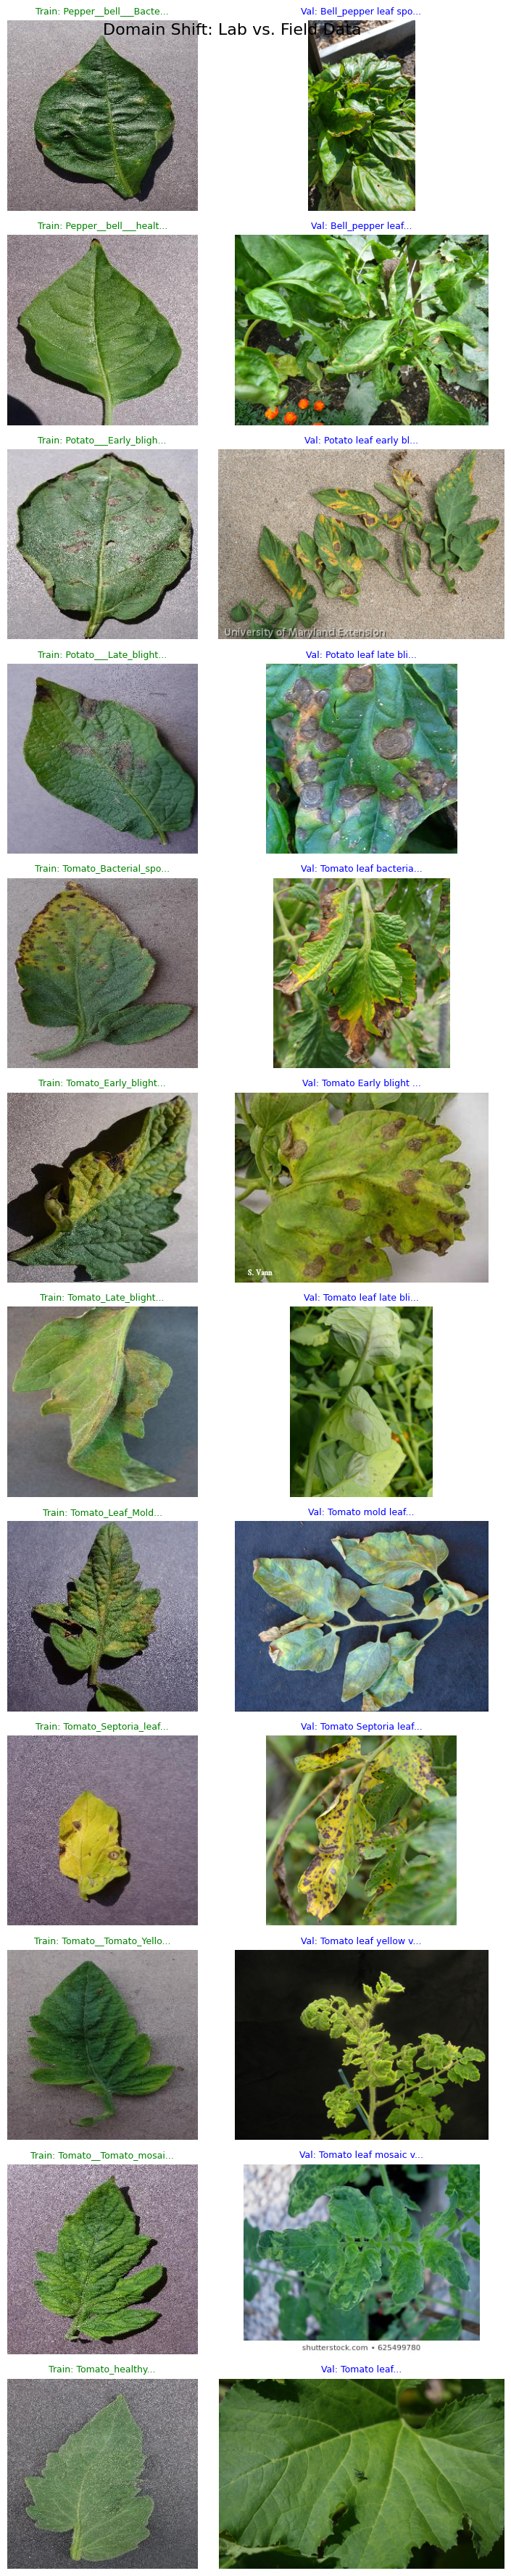

In [14]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

# Use the mapping defined earlier
classes_to_viz = list(CLASS_MAPPING.keys())

# Setup the plot
fig, axes = plt.subplots(len(classes_to_viz), 2, figsize=(8, 3*len(classes_to_viz)))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

def load_random_img(root, class_name):
    class_path = os.path.join(root, class_name)
    if not os.path.exists(class_path): return None
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    if not files: return None
    return Image.open(os.path.join(class_path, random.choice(files)))

print("Generating Domain Shift Visualization...")

for idx, pv_class in enumerate(classes_to_viz):
    img_pv = load_random_img(pv_path, pv_class)
    
    pd_class = CLASS_MAPPING[pv_class]
    img_pd = load_random_img(pd_path, pd_class)
    
    # Plot Left (Train)
    ax_left = axes[idx, 0]
    if img_pv:
        ax_left.imshow(img_pv)
        ax_left.set_title(f"Train: {pv_class[:20]}...", fontsize=9, color='green')
    ax_left.axis('off')

    # Plot Right (Val)
    ax_right = axes[idx, 1]
    if img_pd:
        ax_right.imshow(img_pd)
        ax_right.set_title(f"Val: {pd_class[:20]}...", fontsize=9, color='blue')
    else:
        ax_right.text(0.5, 0.5, "Missing", ha='center')
    ax_right.axis('off')

plt.suptitle("Domain Shift: Lab vs. Field Data", fontsize=16)
plt.tight_layout()
plt.savefig("domain_shift_analysis.png")
plt.show()

In [15]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import ViTModel, ViTConfig
from tqdm.auto import tqdm
import time
from IPython.display import FileLink, display


class BottleneckPatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, pca_dim=128, embed_dim=768, bias=True):
        super().__init__()
        self.img_size = (img_size, img_size)
        self.patch_size = (patch_size, patch_size)
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)

        # The Compression (Bottleneck)
        self.proj1 = nn.Conv2d(in_chans, pca_dim, kernel_size=patch_size, stride=patch_size, bias=False)
        # The Expansion
        self.proj2 = nn.Conv2d(pca_dim, embed_dim, kernel_size=1, stride=1, bias=bias)

        self.projection = self.proj1

    def forward(self, pixel_values, **kwargs):
        B, C, H, W = pixel_values.shape
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        
        # Compress -> Expand -> Flatten to sequence -> Transpose to (Batch, Sequence, Dim)
        x = self.proj2(self.proj1(pixel_values)).flatten(2).transpose(1, 2)
        return x

class ViTTinyBottleneckScratch(nn.Module):
    def __init__(self, num_labels, pca_dim=64):
        super(ViTTinyBottleneckScratch, self).__init__()
        
        config = ViTConfig.from_pretrained("facebook/deit-tiny-patch16-224")
        self.vit = ViTModel(config)
        
        self.vit.embeddings.patch_embeddings = BottleneckPatchEmbed(
            img_size=224, 
            patch_size=16, 
            in_chans=3, 
            pca_dim=pca_dim,  # Compress to 64
            embed_dim=self.vit.config.hidden_size # Expand back
        )
        
        self.classifier = nn.Linear(self.vit.config.hidden_size, num_labels)

    def forward(self, pixel_values):
        vit_out = self.vit(pixel_values=pixel_values).last_hidden_state[:, 0, :]
        return self.classifier(vit_out)

# SETUP
num_classes = len(CLASS_MAPPING) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViTTinyBottleneckScratch(num_classes, pca_dim=64).to(device)

EPOCHS = 30
LR = 2e-5
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

checkpoint_name = "pv_train_pd_val_vit_tiny_bottleneck_64.pth"
start_epoch = 0
best_acc = 0.0

checkpoint_path = "/kaggle/input/models/janishreyas7/bottleneck-16-pv-train-pd-val/pytorch/default/1/pv_train_pd_val_vit_tiny_bottleneck_16_final.pth"

# CHECKPOINT RESUME LOGIC
if os.path.exists(checkpoint_path):
    print(f"Found checkpoint: '{checkpoint_path}'. Loading...")
    
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    if 'epoch' in checkpoint:
        start_epoch = checkpoint['epoch'] + 1 
    else:
        start_epoch = 2 
        
    best_acc = checkpoint.get('accuracy', checkpoint.get('best_val_acc', 0.0))
    print(f"Resuming training for Epoch {start_epoch+1} | Previous Best Acc: {best_acc:.2f}%")
else:
    print("No checkpoint found. Starting from scratch.")


print(f"\nStarting ViT Training (Target: {EPOCHS} Epochs)...")

for epoch in range(start_epoch, EPOCHS):
    start_time = time.time()
    
    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(pixel_values=images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        
        current_acc = 100 * train_correct / train_total
        loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.1f}%")

    # VALIDATE
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Metrics
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    avg_loss = train_loss / train_total
    duration = time.time() - start_time
    
    # Save Best
    saved_tag = ""
    if val_acc > best_acc:
        best_acc = val_acc
        state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'class_names': train_dataset.classes, 
            'num_classes': num_classes,
            'accuracy': best_acc
        }
        torch.save(state, checkpoint_name)
        saved_tag = " [SAVED]"

    print(f"Ep {epoch+1} | {duration:.0f}s | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%{saved_tag}")
    
    if saved_tag:
        display(FileLink(checkpoint_name))

print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.2f}%")


final_checkpoint_name = "pv_train_pd_val_vit_tiny_bottleneck_64_final.pth"

final_state = {
    'epoch': EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names': train_dataset.classes, 
    'num_classes': num_classes,
    'accuracy': val_acc
}

torch.save(final_state, final_checkpoint_name)
print(f"✅ Final epoch model saved to: {final_checkpoint_name}")
display(FileLink(final_checkpoint_name))

No checkpoint found. Starting from scratch.

Starting ViT Training (Target: 30 Epochs)...


Epoch 1/30:   0%|          | 0/544 [00:00<?, ?it/s]

Ep 1 | 334s | Loss: 1.6756 | Train Acc: 42.9% | Val Acc: 9.0% [SAVED]


/kaggle/working/pv_train_pd_val_vit_tiny_bottleneck_64.pth

Epoch 2/30:   0%|          | 0/544 [00:00<?, ?it/s]

...

Epoch 29/30:   0%|          | 0/544 [00:00<?, ?it/s]

Ep 29 | 223s | Loss: 0.1302 | Train Acc: 95.7% | Val Acc: 11.3%


Epoch 30/30:   0%|          | 0/544 [00:00<?, ?it/s]

Ep 30 | 225s | Loss: 0.1215 | Train Acc: 95.7% | Val Acc: 10.7%

Training Complete. Best Validation Accuracy: 11.70%
✅ Final epoch model saved to: pv_train_pd_val_vit_tiny_bottleneck_64_final.pth


/kaggle/working/pv_train_pd_val_vit_tiny_bottleneck_64_final.pth

EVALUATING ON TEST SET
Test Loss: 5.2764
Test Accuracy: 10.68%

DETAILED CLASSIFICATION REPORT
                                       precision    recall  f1-score   support

        Pepper__bell___Bacterial_spot       0.06      0.23      0.09        62
               Pepper__bell___healthy       0.07      0.04      0.05        53
                Potato___Early_blight       0.11      0.05      0.06       109
                 Potato___Late_blight       0.06      0.04      0.05        97
                Tomato_Bacterial_spot       0.04      0.01      0.02        98
                  Tomato_Early_blight       0.09      0.05      0.07        74
                   Tomato_Late_blight       0.14      0.58      0.22       101
                     Tomato_Leaf_Mold       0.11      0.04      0.05        85
            Tomato_Septoria_leaf_spot       0.33      0.01      0.03       137
Tomato__Tomato_YellowLeaf__Curl_Virus       0.14      0.12      0.13        69
          Tomato__Tomato_mosaic_vir

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


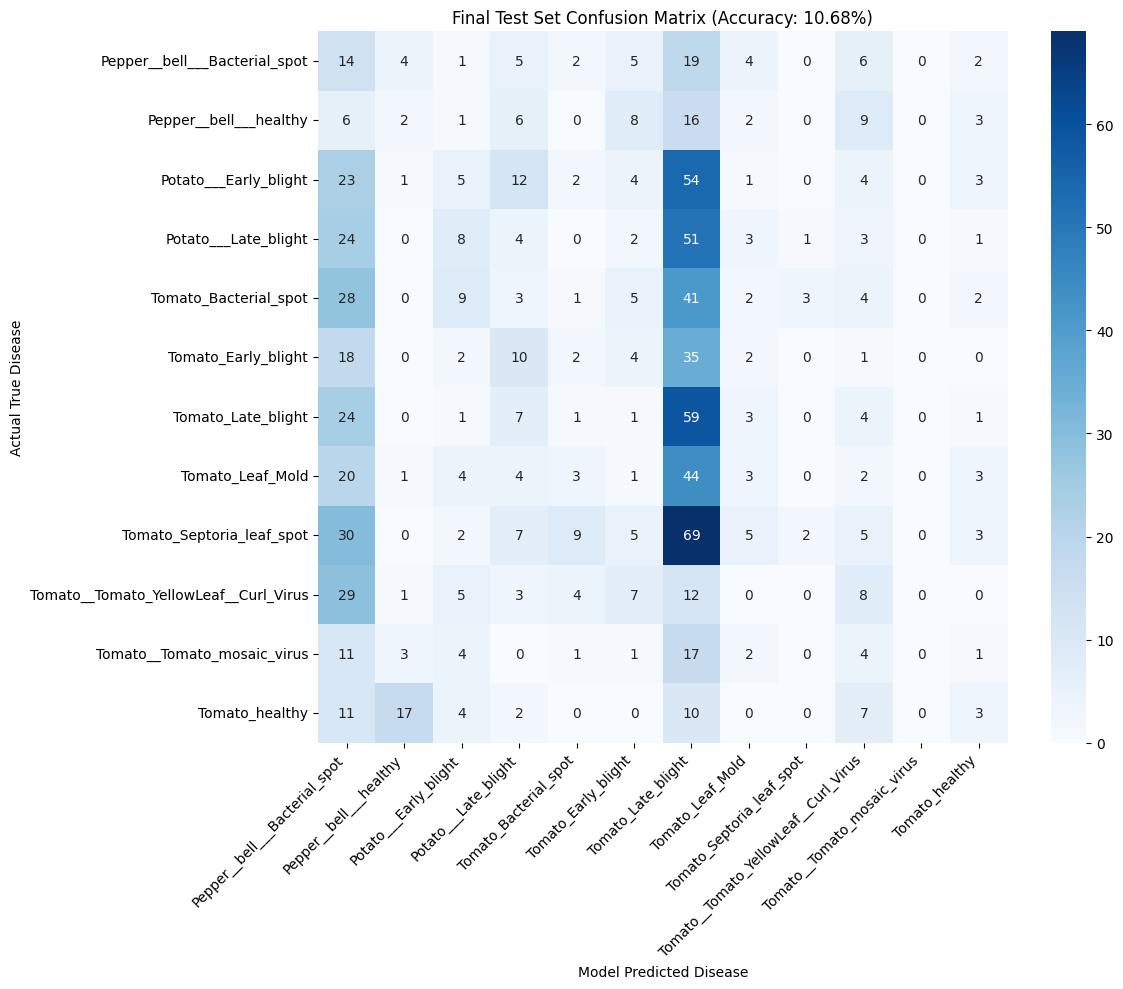

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

print("EVALUATING ON TEST SET")

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(pixel_values=images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        
        # Store for detailed metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall metrics
final_test_acc = 100 * test_correct / test_total
final_test_loss = test_loss / test_total

print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%\n")

class_names = val_dataset.classes

print("DETAILED CLASSIFICATION REPORT")

# Need to check for recall on the minority classes
print(classification_report(all_labels, all_preds, target_names=class_names))


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.ylabel('Actual True Disease')
plt.xlabel('Model Predicted Disease')
plt.title(f'Final Test Set Confusion Matrix (Accuracy: {final_test_acc:.2f}%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()